# Boy or Girl 2026 NEW - EDA (Exploratory Data Analysis)

> **目標**: 全面理解數據集特性，為後續 Baseline 訓練提供依據
>
> **對應文檔**: `training_workflow.md` 階段 1
>
> **建議方法**: 統計分析 + 可視化分析 + 相關性分析

---

## 📋 分析目標

1. 數據集基本信息（樣本數、特徵數、目標變量分佈）
2. 特徵類型清單（數值型 vs 類別型）
3. 缺失值統計
4. 異常值識別
5. 特徵相關性分析
6. 按性別分組的統計特徵

---

## ⚠️ 數據集準備檢查

**在運行此 notebook 前，請確保：**

1. 已從 Kaggle 下載數據集：[Boy or Girl 2026 NEW](https://www.kaggle.com/competitions/boy-or-girl-2026-new/data)
2. 創建 `dataset/` 目錄（如果不存在）
3. 將 `train.csv` 和 `test.csv` 放入 `dataset/` 目錄

```bash
# 在項目根目錄執行
mkdir -p dataset
# 然後將下載的 train.csv 和 test.csv 複製到 dataset/ 目錄
```

## 1. 環境設置

In [1]:
# 導入必要的庫
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# 設置
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# 顯示設置
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 3)

# 隨機種子（可重現性）
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✓ 環境設置完成")
print(f"Pandas版本: {pd.__version__}")
print(f"NumPy版本: {np.__version__}")
print(f"Matplotlib版本: {plt.matplotlib.__version__}")
print(f"Seaborn版本: {sns.__version__}")

✓ 環境設置完成
Pandas版本: 2.2.3
NumPy版本: 2.3.4
Matplotlib版本: 3.10.0
Seaborn版本: 0.13.2


## 2. 數據加載

In [2]:
# 數據路徑
DATA_DIR = Path('../dataset')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'

# 檢查數據集是否存在
if not TRAIN_PATH.exists():
    print("❌ 錯誤：找不到 train.csv")
    print(f"   預期路徑：{TRAIN_PATH.absolute()}")
    print("\n請按照上方指引準備數據集後再運行此 notebook")
    raise FileNotFoundError("數據集未準備好")

# 加載訓練數據
print("正在加載數據...")
train_df = pd.read_csv(TRAIN_PATH)
print(f"✓ 訓練數據加載完成：{train_df.shape[0]} 行 × {train_df.shape[1]} 列")

# 測試集僅用於檢查特徵分佈一致性（可選）
test_df = None
if TEST_PATH.exists():
    test_df = pd.read_csv(TEST_PATH)
    print(f"✓ 測試數據加載完成：{test_df.shape[0]} 行 × {test_df.shape[1]} 列")
    print("   註：測試集僅用於檢查特徵分佈，不參與 EDA 分析")
else:
    print("⚠ 未找到測試數據（不影響 EDA）")

正在加載數據...
✓ 訓練數據加載完成：423 行 × 11 列
✓ 測試數據加載完成：426 行 × 11 列
   註：測試集僅用於檢查特徵分佈，不參與 EDA 分析


## 3. 數據集基本信息

In [3]:
# 3.1 數據形狀
print("="*60)
print("數據集基本信息")
print("="*60)
print(f"訓練集樣本數：{train_df.shape[0]}")
print(f"特徵數量：{train_df.shape[1]}")
print(f"\n列名：{list(train_df.columns)}")

數據集基本信息
訓練集樣本數：423
特徵數量：11

列名：['id', 'gender', 'star_sign', 'phone_os', 'height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt', 'self_intro']


In [4]:
# 3.2 數據類型和缺失值
print("\n" + "="*60)
print("數據類型和缺失值摘要")
print("="*60)
train_df.info()


數據類型和缺失值摘要
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          423 non-null    int64  
 1   gender      423 non-null    int64  
 2   star_sign   337 non-null    object 
 3   phone_os    345 non-null    object 
 4   height      349 non-null    float64
 5   weight      338 non-null    float64
 6   sleepiness  332 non-null    float64
 7   iq          344 non-null    float64
 8   fb_friends  346 non-null    float64
 9   yt          333 non-null    object 
 10  self_intro  319 non-null    object 
dtypes: float64(5), int64(2), object(4)
memory usage: 36.5+ KB


In [5]:
# 3.3 前幾行數據
print("\n" + "="*60)
print("前 5 行數據預覽")
print("="*60)
train_df.head()


前 5 行數據預覽


,id,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
0,1,2,處女座,Apple,154.0,43.0,NaN,NaN,583.0,0,Beautiful
1,2,2,處女座,Apple,156.0,47.0,NaN,130.0,NaN,3.5,Enjoying being who I'm notsss
2,3,1,射手座,NaN,170.0,61.0,NaN,90.0,540.0,NaN,Practice Makes perfect
3,4,1,射手座,Apple,170.0,62.0,4.0,100.0,NaN,5,Straightforward
4,5,2,射手座,Android,158.0,67.0,NaN,128.0,320.0,1.2,Humorous


## 4. 目標變量分析

目標變量 (gender) 分佈

絕對數量：
gender
1    316
2    107
Name: count, dtype: int64

比例分佈：
  1: 74.70%
  2: 25.30%


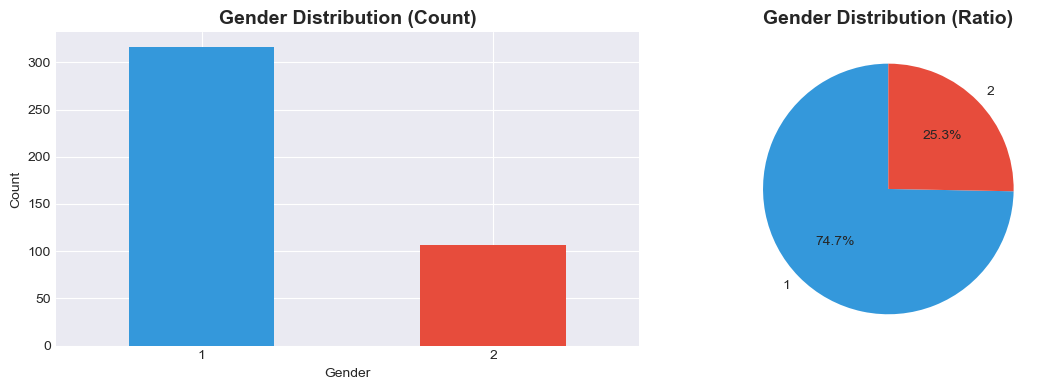


【類別平衡性評估】
不平衡比例：2.95:1
⚠ 輕度不平衡（1.5 ≤ 比例 < 3）- 建議使用 class_weight


In [6]:
# 4.1 目標變量分佈
if 'gender' in train_df.columns:
    print("="*60)
    print("目標變量 (gender) 分佈")
    print("="*60)
    
    # 計數統計
    gender_counts = train_df['gender'].value_counts()
    gender_ratio = train_df['gender'].value_counts(normalize=True)
    
    print("\n絕對數量：")
    print(gender_counts)
    
    print("\n比例分佈：")
    for label, ratio in gender_ratio.items():
        print(f"  {label}: {ratio:.2%}")
    
    # 視覺化
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 柱狀圖
    gender_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
    axes[0].set_title('Gender Distribution (Count)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Gender')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)
    
    # 餅圖
    axes[1].pie(gender_ratio.values, labels=gender_ratio.index, autopct='%1.1f%%',
                colors=['#3498db', '#e74c3c'], startangle=90)
    axes[1].set_title('Gender Distribution (Ratio)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 平衡性評估
    imbalance_ratio = max(gender_ratio) / min(gender_ratio)
    print(f"\n【類別平衡性評估】")
    print(f"不平衡比例：{imbalance_ratio:.2f}:1")
    if imbalance_ratio < 1.5:
        print("✓ 類別相對平衡（比例 < 1.5）")
    elif imbalance_ratio < 3:
        print("⚠ 輕度不平衡（1.5 ≤ 比例 < 3）- 建議使用 class_weight")
    else:
        print("❌ 嚴重不平衡（比例 ≥ 3）- 需要處理（SMOTE 或 class_weight）")
else:
    print("⚠ 警告：找不到 'gender' 欄位")

## 5. 特徵類型分類

In [7]:
# 5.1 識別數值型和類別型特徵
# 移除 ID 欄位和目標變量
feature_cols = [col for col in train_df.columns if col not in ['Id', 'ID', 'id', 'Gender']]

# 數值型特徵
numeric_features = train_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# 類別型特徵（包括 object 類型）
categorical_features = train_df[feature_cols].select_dtypes(include=['object']).columns.tolist()

print("="*60)
print("特徵類型分類")
print("="*60)
print(f"\n數值型特徵（{len(numeric_features)}個）：")
print(numeric_features)

print(f"\n類別型特徵（{len(categorical_features)}個）：")
print(categorical_features)

print(f"\n總特徵數：{len(feature_cols)}")

特徵類型分類

數值型特徵（6個）：
['gender', 'height', 'weight', 'sleepiness', 'iq', 'fb_friends']

類別型特徵（4個）：
['star_sign', 'phone_os', 'yt', 'self_intro']

總特徵數：10


## 6. 缺失值分析

缺失值統計

發現 9 個特徵有缺失值：

            總樣本數  缺失數量  非空數量  缺失比例(%)
self_intro   423   104   319    24.59
sleepiness   423    91   332    21.51
yt           423    90   333    21.28
star_sign    423    86   337    20.33
weight       423    85   338    20.09
iq           423    79   344    18.68
phone_os     423    78   345    18.44
fb_friends   423    77   346    18.20
height       423    74   349    17.49


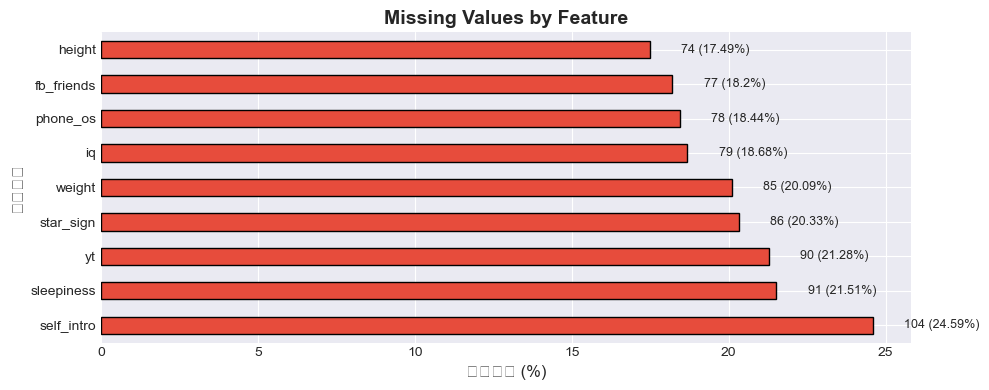


缺失值嚴重程度評估

⚠ 中等缺失（20-50%）：5 個特徵
   建議：需要謹慎選擇填補策略，或考慮是否有預測價值
   - self_intro: 104 個 (24.59%) [object]
   - sleepiness: 91 個 (21.51%) [float64]
   - yt: 90 個 (21.28%) [object]
   - star_sign: 86 個 (20.33%) [object]
   - weight: 85 個 (20.09%) [float64]

✓ 低缺失（<20%）：4 個特徵
   建議：可以使用標準填補方法
   - iq: 79 個 (18.68%) [float64]
   - phone_os: 78 個 (18.44%) [object]
   - fb_friends: 77 個 (18.2%) [float64]
   - height: 74 個 (17.49%) [float64]

初步填補策略建議（待討論）

【數值型特徵】
  - sleepiness (21.51%): 建議用 median 填補
  - weight (20.09%): 建議用 median 填補
  - iq (18.68%): 建議用 median 填補
  - fb_friends (18.2%): 建議用 median 填補
  - height (17.49%): 建議用 median 填補

【類別型特徵】
  - self_intro (24.59%): 建議用 most_frequent 填補或創建 'Unknown'
  - yt (21.28%): 建議用 most_frequent 填補或創建 'Unknown'
  - star_sign (20.33%): 建議用 most_frequent 填補或創建 'Unknown'
  - phone_os (18.44%): 建議用 most_frequent 填補或創建 'Unknown'

⚠️ 註：以上僅為初步建議，具體策略需要結合特徵重要性和業務邏輯討論決定


In [8]:
# 6.1 缺失值統計
print("="*60)
print("缺失值統計")
print("="*60)

# 計算缺失值
missing_stats = pd.DataFrame({
    '總樣本數': len(train_df),
    '缺失數量': train_df.isnull().sum(),
    '非空數量': train_df.notnull().sum(),
    '缺失比例(%)': (train_df.isnull().sum() / len(train_df) * 100).round(2)
})

# 只顯示有缺失的特徵
missing_features = missing_stats[missing_stats['缺失數量'] > 0].copy()
missing_features = missing_features.sort_values('缺失比例(%)', ascending=False)

if len(missing_features) > 0:
    print(f"\n發現 {len(missing_features)} 個特徵有缺失值：\n")
    print(missing_features.to_string())
    
    # 視覺化缺失值
    plt.figure(figsize=(10, max(4, len(missing_features) * 0.3)))
    
    # 繪製缺失比例
    ax = missing_features['缺失比例(%)'].plot(
        kind='barh', 
        color='#e74c3c',
        edgecolor='black'
    )
    ax.set_xlabel('缺失比例 (%)', fontsize=12)
    ax.set_ylabel('特徵名稱', fontsize=12)
    ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
    
    # 在柱狀圖上標註數量
    for idx, (feature, row) in enumerate(missing_features.iterrows()):
        ax.text(
            row['缺失比例(%)'] + 1, 
            idx, 
            f"{int(row['缺失數量'])} ({row['缺失比例(%)']}%)",
            va='center',
            fontsize=9
        )
    
    plt.tight_layout()
    plt.show()
    
    # 缺失值嚴重程度評估
    print("\n" + "="*60)
    print("缺失值嚴重程度評估")
    print("="*60)
    
    high_missing = missing_features[missing_features['缺失比例(%)'] > 50]
    medium_missing = missing_features[(missing_features['缺失比例(%)'] > 20) & (missing_features['缺失比例(%)'] <= 50)]
    low_missing = missing_features[missing_features['缺失比例(%)'] <= 20]
    
    if len(high_missing) > 0:
        print(f"\n❌ 高缺失（>50%）：{len(high_missing)} 個特徵")
        print("   建議：考慮刪除或創建二元特徵（has_xxx）")
        for feature in high_missing.index:
            print(f"   - {feature}: {high_missing.loc[feature, '缺失數量']:.0f} 個 ({high_missing.loc[feature, '缺失比例(%)']}%)")
    
    if len(medium_missing) > 0:
        print(f"\n⚠ 中等缺失（20-50%）：{len(medium_missing)} 個特徵")
        print("   建議：需要謹慎選擇填補策略，或考慮是否有預測價值")
        for feature in medium_missing.index:
            feat_type = train_df[feature].dtype
            print(f"   - {feature}: {medium_missing.loc[feature, '缺失數量']:.0f} 個 ({medium_missing.loc[feature, '缺失比例(%)']}%) [{feat_type}]")
    
    if len(low_missing) > 0:
        print(f"\n✓ 低缺失（<20%）：{len(low_missing)} 個特徵")
        print("   建議：可以使用標準填補方法")
        for feature in low_missing.index:
            feat_type = train_df[feature].dtype
            print(f"   - {feature}: {low_missing.loc[feature, '缺失數量']:.0f} 個 ({low_missing.loc[feature, '缺失比例(%)']}%) [{feat_type}]")
    
    # 針對特徵類型給出初步建議
    print("\n" + "="*60)
    print("初步填補策略建議（待討論）")
    print("="*60)
    
    numeric_missing = [f for f in missing_features.index if f in numeric_features]
    categorical_missing = [f for f in missing_features.index if f in categorical_features]
    
    if numeric_missing:
        print("\n【數值型特徵】")
        for feature in numeric_missing:
            pct = missing_features.loc[feature, '缺失比例(%)']
            if pct > 30:
                print(f"  - {feature} ({pct}%): 缺失過多，考慮刪除或創建 'is_missing' 特徵")
            else:
                print(f"  - {feature} ({pct}%): 建議用 median 填補")
    
    if categorical_missing:
        print("\n【類別型特徵】")
        for feature in categorical_missing:
            pct = missing_features.loc[feature, '缺失比例(%)']
            if pct > 30:
                print(f"  - {feature} ({pct}%): 缺失過多，建議創建 'Unknown' 類別")
            else:
                print(f"  - {feature} ({pct}%): 建議用 most_frequent 填補或創建 'Unknown'")
    
    print("\n⚠️ 註：以上僅為初步建議，具體策略需要結合特徵重要性和業務邏輯討論決定")
    
else:
    print("\n✓ 沒有缺失值！數據完整。")

## 7. 數值型特徵分析

In [9]:
# 7.1 數值型特徵基本統計
if len(numeric_features) > 0:
    print("="*60)
    print("數值型特徵統計摘要")
    print("="*60)
    print(train_df[numeric_features].describe().T)

數值型特徵統計摘要
            count        mean         std     min    25%    50%     75%  \
gender      423.0   1.253e+00   4.352e-01     1.0    1.0    1.0    2.00   
height      349.0  2.865e+108  5.353e+109  -187.0  165.0  171.0  176.00   
weight      338.0  2.959e+108  5.439e+109 -1000.0   55.0   64.5   72.75   
sleepiness  332.0   3.419e+00   1.223e+00     1.0    3.0    3.0    4.00   
iq          344.0   1.247e+02   3.768e+01    50.0  100.0  120.0  145.00   
fb_friends  346.0   1.252e+07   1.756e+08 -1000.0  200.0  400.0  700.00   

                   max  
gender       2.000e+00  
height      1.000e+111  
weight      1.000e+111  
sleepiness   5.000e+00  
iq           2.000e+02  
fb_friends   3.000e+09  


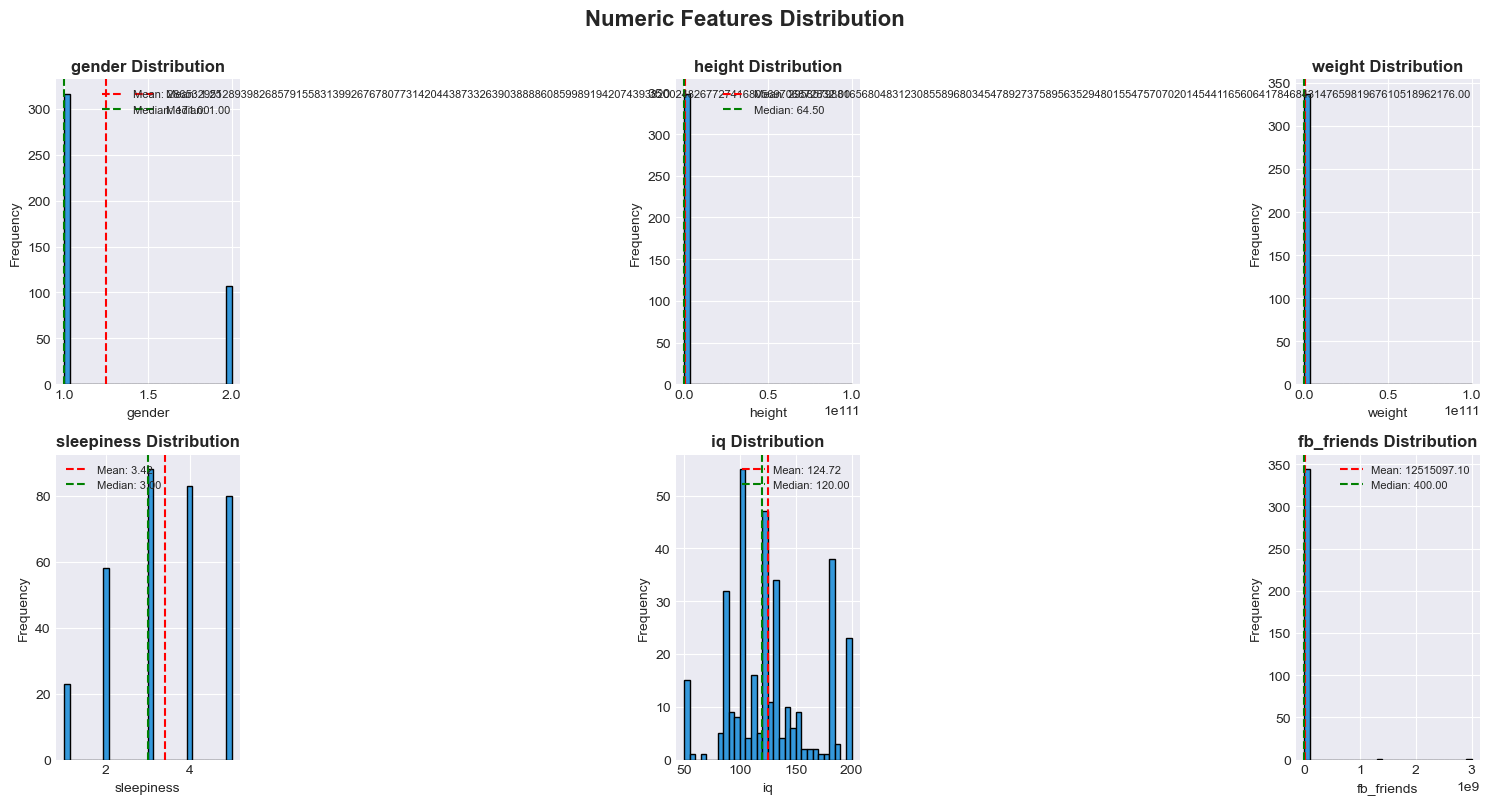

In [10]:
# 7.2 數值型特徵分佈（直方圖）
if len(numeric_features) > 0:
    n_cols = 3
    n_rows = (len(numeric_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, feature in enumerate(numeric_features):
        train_df[feature].hist(bins=30, ax=axes[idx], color='#3498db', edgecolor='black')
        axes[idx].set_title(f'{feature} Distribution', fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        
        # 添加統計信息
        mean_val = train_df[feature].mean()
        median_val = train_df[feature].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
        axes[idx].legend(fontsize=8)
    
    # 隱藏多餘的子圖
    for idx in range(len(numeric_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Numeric Features Distribution', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

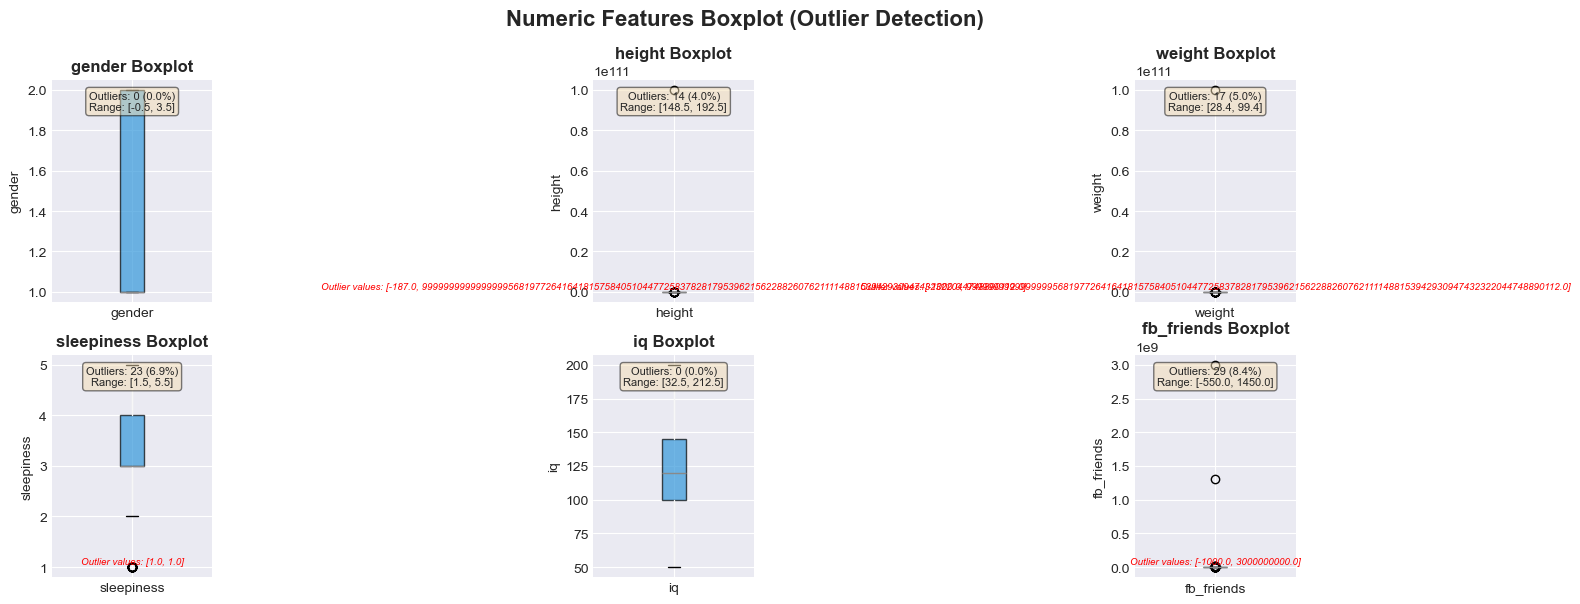


離群值統計摘要（IQR 方法：1.5 × IQR）

        特徵  有效樣本  離群值數量 離群值比例(%)             正常範圍                                                                                                                        離群值範圍
    gender   423      0      0.0      [-0.5, 3.5]                                                                                                                            無
    height   349     14      4.0   [148.5, 192.5]  [-187.0, 999999999999999956819772641641815758405104477258378281795396215622882607621111488153942930947432322044748890112.0]
    weight   338     17      5.0     [28.4, 99.4] [-1000.0, 999999999999999956819772641641815758405104477258378281795396215622882607621111488153942930947432322044748890112.0]
sleepiness   332     23      6.9       [1.5, 5.5]                                                                                                                   [1.0, 1.0]
        iq   344      0      0.0    [32.5, 212.5]                                                

In [11]:
# 7.3 數值型特徵箱線圖（識別離群值）
if len(numeric_features) > 0:
    n_cols = 3
    n_rows = (len(numeric_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, feature in enumerate(numeric_features):
        train_df.boxplot(column=feature, ax=axes[idx], patch_artist=True,
                        boxprops=dict(facecolor='#3498db', alpha=0.7))
        axes[idx].set_title(f'{feature} Boxplot', fontweight='bold')
        axes[idx].set_ylabel(feature)
        
        # ✅ 修正：先移除缺失值再計算離群值
        data_clean = train_df[feature].dropna()
        
        if len(data_clean) > 0:
            Q1 = data_clean.quantile(0.25)
            Q3 = data_clean.quantile(0.75)
            IQR = Q3 - Q1
            
            # 計算離群值邊界
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # 識別離群值
            outliers = data_clean[(data_clean < lower_bound) | (data_clean > upper_bound)]
            n_outliers = len(outliers)
            
            # 計算離群值比例
            outlier_pct = (n_outliers / len(data_clean)) * 100
            
            # 顯示統計信息
            text = f'Outliers: {n_outliers} ({outlier_pct:.1f}%)\n'
            text += f'Range: [{lower_bound:.1f}, {upper_bound:.1f}]'
            
            axes[idx].text(0.5, 0.95, text, 
                          transform=axes[idx].transAxes, 
                          ha='center', va='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                          fontsize=8)
            
            # 如果有離群值，顯示其範圍
            if n_outliers > 0:
                outlier_range = f'Outlier values: [{outliers.min():.1f}, {outliers.max():.1f}]'
                axes[idx].text(0.5, 0.05, outlier_range,
                              transform=axes[idx].transAxes,
                              ha='center', va='bottom',
                              fontsize=7, style='italic', color='red')
    
    # 隱藏多餘的子圖
    for idx in range(len(numeric_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Numeric Features Boxplot (Outlier Detection)', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # 輸出離群值統計摘要
    print("\n" + "="*60)
    print("離群值統計摘要（IQR 方法：1.5 × IQR）")
    print("="*60)
    
    outlier_summary = []
    for feature in numeric_features:
        data_clean = train_df[feature].dropna()
        if len(data_clean) > 0:
            Q1 = data_clean.quantile(0.25)
            Q3 = data_clean.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = data_clean[(data_clean < lower_bound) | (data_clean > upper_bound)]
            
            outlier_summary.append({
                '特徵': feature,
                '有效樣本': len(data_clean),
                '離群值數量': len(outliers),
                '離群值比例(%)': f"{(len(outliers)/len(data_clean)*100):.1f}",
                '正常範圍': f"[{lower_bound:.1f}, {upper_bound:.1f}]",
                '離群值範圍': f"[{outliers.min():.1f}, {outliers.max():.1f}]" if len(outliers) > 0 else "無"
            })
    
    outlier_df = pd.DataFrame(outlier_summary)
    print("\n" + outlier_df.to_string(index=False))
    
    # 判斷是否需要處理
    high_outlier_features = outlier_df[outlier_df['離群值比例(%)'].astype(float) > 5]
    if len(high_outlier_features) > 0:
        print("\n⚠ 發現高比例離群值特徵（>5%）：")
        for _, row in high_outlier_features.iterrows():
            print(f"  - {row['特徵']}: {row['離群值數量']} 個 ({row['離群值比例(%)']}%)")
        print("  建議：檢查數據質量，或考慮使用更穩健的方法（如 RobustScaler）")

## 8. 異常值詳細分析

In [12]:
# 8.1 識別明顯不合理的值
if len(numeric_features) > 0:
    print("="*60)
    print("異常值檢測（基於領域知識）")
    print("="*60)
    
    # 檢查每個數值特徵的合理性
    anomaly_rules = {
        'height': (50, 250, 'cm'),      # 人類身高合理範圍
        'weight': (20, 200, 'kg'),      # 人類體重合理範圍
        'iq': (50, 200, '分'),           # IQ 合理範圍
        'age': (0, 120, '歲'),          # 年齡合理範圍
    }
    
    anomaly_found = False
    for feature in numeric_features:
        # 檢查負值
        negative_count = (train_df[feature] < 0).sum()
        if negative_count > 0:
            print(f"\n❌ {feature}: 發現 {negative_count} 個負值")
            anomaly_found = True
        
        # 檢查零值（某些特徵不應為0）
        zero_count = (train_df[feature] == 0).sum()
        if zero_count > 0 and feature in ['height', 'weight', 'iq']:
            print(f"⚠ {feature}: 發現 {zero_count} 個零值（可能不合理）")
            anomaly_found = True
        
        # 檢查超出合理範圍的值
        if feature in anomaly_rules:
            min_val, max_val, unit = anomaly_rules[feature]
            out_of_range = train_df[(train_df[feature] < min_val) | (train_df[feature] > max_val)][feature]
            if len(out_of_range) > 0:
                print(f"\n❌ {feature}: 發現 {len(out_of_range)} 個超出合理範圍 [{min_val}, {max_val}] {unit} 的值")
                print(f"   範圍：{out_of_range.min():.2f} ~ {out_of_range.max():.2f}")
                anomaly_found = True
    
    if not anomaly_found:
        print("\n✓ 未發現明顯異常值")

異常值檢測（基於領域知識）

❌ height: 發現 1 個負值

❌ height: 發現 6 個超出合理範圍 [50, 250] cm 的值
   範圍：-187.00 ~ 999999999999999956819772641641815758405104477258378281795396215622882607621111488153942930947432322044748890112.00

❌ weight: 發現 1 個負值

❌ weight: 發現 7 個超出合理範圍 [20, 200] kg 的值
   範圍：-1000.00 ~ 999999999999999956819772641641815758405104477258378281795396215622882607621111488153942930947432322044748890112.00

❌ fb_friends: 發現 1 個負值


## 9. 類別型特徵分析

類別型特徵分佈

【star_sign】
唯一值數量：12

分佈：
star_sign
雙魚座    38
獅子座    35
水瓶座    34
天秤座    33
巨蟹座    31
雙子座    28
處女座    26
摩羯座    26
射手座    23
天蠍座    23
牡羊座    21
金牛座    19


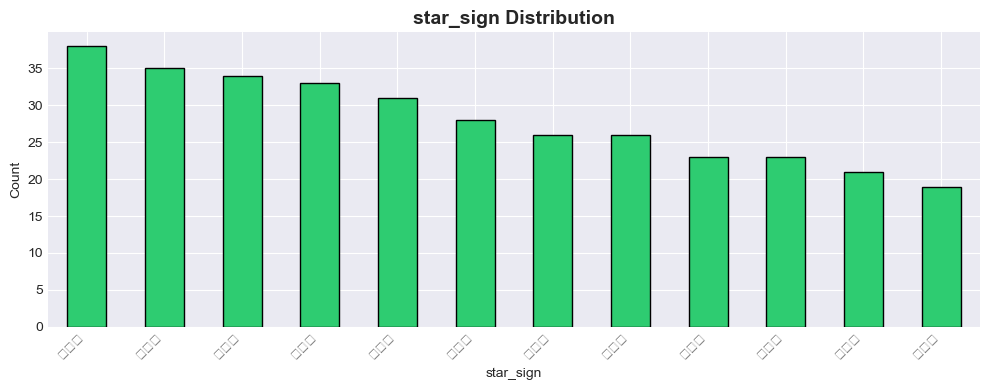


【phone_os】
唯一值數量：4

分佈：
phone_os
Android          188
Apple            155
Windows Phone      1
JohnCena           1


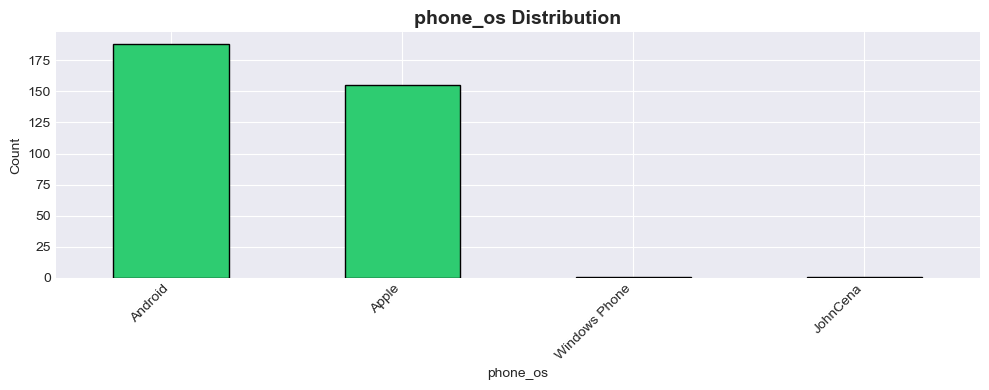


【yt】
唯一值數量：94

分佈：
yt
1             48
0             25
2             25
5             22
3             19
10            13
0.5           12
4              9
100            8
0.1            6
6              5
20             5
999            5
87             4
99999          4
38             4
0.87           4
64             4
0.3            4
1.2            3
3.5            3
1.5            3
0.2            3
8              3
0.01           3
15             3
1.4            3
0.003          2
8.2            2
6.77           2
12             2
2.41           2
1.1            2
9              2
500            2
0.79           2
5000           2
2.5            2
41             2
1.7            2
50             2
200            2
9.59           2
0.000214       1
7              1
5.87           1
9999           1
12.49          1
16.2           1
88888          1
16             1
19             1
2048           1
-1000          1
0.48           1
99.4           1
14.32          1
0.000351

In [13]:
# 9.1 類別型特徵分佈
if len(categorical_features) > 0:
    print("="*60)
    print("類別型特徵分佈")
    print("="*60)
    
    for feature in categorical_features:
        print(f"\n【{feature}】")
        value_counts = train_df[feature].value_counts()
        print(f"唯一值數量：{train_df[feature].nunique()}")
        print(f"\n分佈：")
        print(value_counts.to_string())
        
        # 視覺化（如果類別數不太多）
        if train_df[feature].nunique() <= 20:
            plt.figure(figsize=(10, 4))
            value_counts.plot(kind='bar', color='#2ecc71', edgecolor='black')
            plt.title(f'{feature} Distribution', fontsize=14, fontweight='bold')
            plt.xlabel(feature)
            plt.ylabel('Count')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
else:
    print("\n沒有類別型特徵")

## 10. 特徵相關性分析

數值型特徵相關性分析


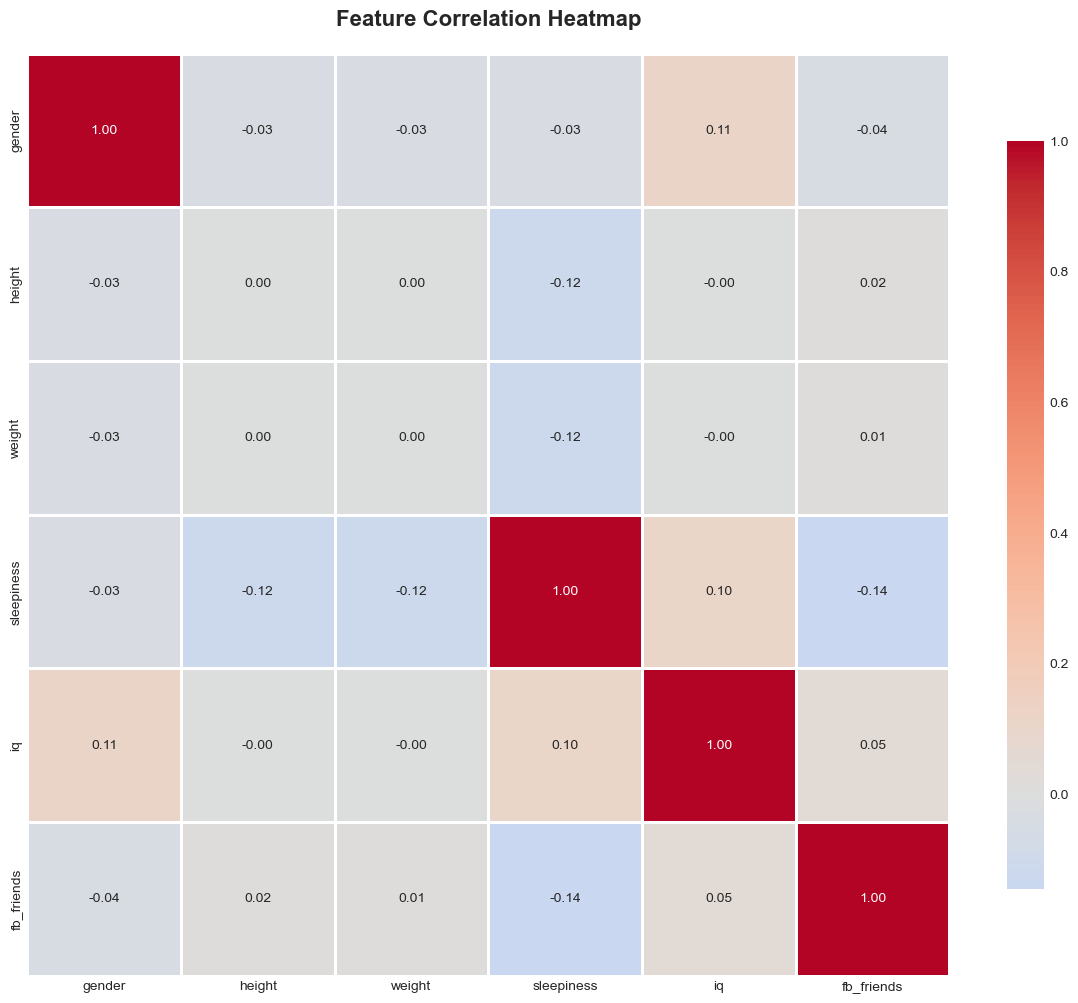


【高度相關特徵對（|r| > 0.8）】
  ✓ 沒有高度相關的特徵對


In [14]:
# 10.1 數值型特徵相關性矩陣
if len(numeric_features) > 1:
    print("="*60)
    print("數值型特徵相關性分析")
    print("="*60)
    
    # 計算相關性矩陣
    corr_matrix = train_df[numeric_features].corr()
    
    # 視覺化熱力圖
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # 識別高度相關的特徵對
    high_corr_threshold = 0.8
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))
    
    print(f"\n【高度相關特徵對（|r| > {high_corr_threshold}）】")
    if high_corr_pairs:
        for feat1, feat2, corr_val in high_corr_pairs:
            print(f"  {feat1} ↔ {feat2}: r = {corr_val:.3f}")
        print("\n⚠ 建議：考慮移除其中一個特徵以避免多重共線性")
    else:
        print("  ✓ 沒有高度相關的特徵對")

In [15]:
# 10.2 特徵與目標變量的相關性（如果目標是數值型編碼）
if 'Gender' in train_df.columns and len(numeric_features) > 0:
    # 將性別編碼為數值
    gender_encoded = train_df['Gender'].map({'Boy': 0, 'Girl': 1, 'M': 0, 'F': 1, 'Male': 0, 'Female': 1})
    
    if gender_encoded.notna().sum() > 0:
        print("\n" + "="*60)
        print("特徵與目標變量的相關性")
        print("="*60)
        
        target_corr = train_df[numeric_features].corrwith(gender_encoded).sort_values(ascending=False)
        
        print("\n相關性排序（絕對值降序）：")
        print(target_corr.abs().sort_values(ascending=False).to_string())
        
        # 視覺化
        plt.figure(figsize=(10, max(4, len(numeric_features) * 0.3)))
        target_corr.sort_values().plot(kind='barh', color=['red' if x < 0 else 'green' for x in target_corr.sort_values()])
        plt.xlabel('Correlation with Gender')
        plt.title('Feature Correlation with Target (Gender)', fontsize=14, fontweight='bold')
        plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
        plt.tight_layout()
        plt.show()

## 11. 按性別分組的特徵分析

In [16]:
# 11.1 數值特徵按性別分組的統計
if 'Gender' in train_df.columns and len(numeric_features) > 0:
    print("="*60)
    print("數值特徵按性別分組統計（均值）")
    print("="*60)
    
    grouped_mean = train_df.groupby('Gender')[numeric_features].mean()
    print("\n均值對比：")
    print(grouped_mean.T.to_string())
    
    # 計算差異顯著性（簡單的差異比例）
    if len(grouped_mean) == 2:
        diff = grouped_mean.iloc[0] - grouped_mean.iloc[1]
        diff_pct = (diff / grouped_mean.mean()) * 100
        
        print("\n差異百分比（相對於整體均值）：")
        print(diff_pct.abs().sort_values(ascending=False).to_string())
        
        # 視覺化差異最大的前幾個特徵
        top_diff_features = diff_pct.abs().sort_values(ascending=False).head(min(6, len(diff_pct)))
        
        if len(top_diff_features) > 0:
            n_features = len(top_diff_features)
            fig, axes = plt.subplots(2, 3, figsize=(15, 8))
            axes = axes.flatten()
            
            for idx, feature in enumerate(top_diff_features.index):
                train_df.boxplot(column=feature, by='Gender', ax=axes[idx],
                               patch_artist=True)
                axes[idx].set_title(f'{feature}', fontweight='bold')
                axes[idx].set_xlabel('Gender')
                axes[idx].set_ylabel(feature)
                plt.sca(axes[idx])
                plt.xticks(rotation=0)
            
            # 隱藏多餘子圖
            for idx in range(n_features, 6):
                axes[idx].axis('off')
            
            plt.suptitle('Top Features with Gender Differences', fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()

## 12. EDA 總結與建議

In [17]:
# 12.1 生成 EDA 總結報告
print("="*60)
print("EDA 總結報告")
print("="*60)

print(f"\n【數據集基本信息】")
print(f"  ✓ 訓練樣本數：{len(train_df)}")
print(f"  ✓ 特徵總數：{len(feature_cols)}")
print(f"    - 數值型：{len(numeric_features)}")
print(f"    - 類別型：{len(categorical_features)}")

if 'Gender' in train_df.columns:
    print(f"\n【目標變量】")
    print(f"  ✓ 類別分佈：{dict(train_df['Gender'].value_counts())}")
    imbalance_ratio = train_df['Gender'].value_counts().max() / train_df['Gender'].value_counts().min()
    print(f"  ✓ 不平衡比例：{imbalance_ratio:.2f}:1")

print(f"\n【缺失值】")
if len(missing_stats) > 0:
    print(f"  ⚠ 有缺失值的特徵：{len(missing_stats)} 個")
    print(f"    - 高缺失（>50%）：{len(missing_stats[missing_stats['缺失比例'] > 50])} 個")
    print(f"    - 中等缺失（10-50%）：{len(missing_stats[(missing_stats['缺失比例'] > 10) & (missing_stats['缺失比例'] <= 50)])} 個")
    print(f"    - 低缺失（<10%）：{len(missing_stats[missing_stats['缺失比例'] <= 10])} 個")
else:
    print(f"  ✓ 無缺失值")

print(f"\n【特徵相關性】")
if len(numeric_features) > 1:
    if high_corr_pairs:
        print(f"  ⚠ 發現 {len(high_corr_pairs)} 對高度相關特徵（|r| > {high_corr_threshold}）")
    else:
        print(f"  ✓ 無高度相關特徵對")

print("\n【後續建議】")
print("  1. 數據清洗：")
if anomaly_found:
    print("     - 處理檢測到的異常值（參考上方異常值分析）")
print("     - 執行去重檢查")

if len(missing_stats) > 0:
    print("  2. 缺失值處理：")
    print("     - 數值型：使用 median 填補")
    print("     - 類別型：使用 most_frequent 填補")

if high_corr_pairs:
    print("  3. 特徵工程：")
    print("     - 考慮移除高度相關特徵對中的一個")

print("  4. 模型選擇：")
print("     - Baseline: Logistic Regression")
print("     - 主模型: Random Forest (適合小樣本)")

print("\n✓ EDA 完成！請根據以上分析調整 training_workflow.md 中的參數設置")

EDA 總結報告

【數據集基本信息】
  ✓ 訓練樣本數：423
  ✓ 特徵總數：10
    - 數值型：6
    - 類別型：4

【缺失值】
  ⚠ 有缺失值的特徵：11 個


KeyError: '缺失比例'

## 13. 導出 EDA 結果（可選）

In [ ]:
# 13.1 保存 EDA 統計摘要到文件
output_dir = Path('../results/eda')
output_dir.mkdir(parents=True, exist_ok=True)

# 保存基本統計
if len(numeric_features) > 0:
    train_df[numeric_features].describe().to_csv(output_dir / 'numeric_features_summary.csv')
    print(f"✓ 數值特徵統計已保存：{output_dir / 'numeric_features_summary.csv'}")

# 保存缺失值統計
if len(missing_stats) > 0:
    missing_stats.to_csv(output_dir / 'missing_values.csv')
    print(f"✓ 缺失值統計已保存：{output_dir / 'missing_values.csv'}")

# 保存相關性矩陣
if len(numeric_features) > 1:
    corr_matrix.to_csv(output_dir / 'correlation_matrix.csv')
    print(f"✓ 相關性矩陣已保存：{output_dir / 'correlation_matrix.csv'}")

print("\n✓ 訓練集 EDA 結果導出完成！")

✓ 數值特徵統計已保存：..\results\eda\numeric_features_summary.csv
✓ 缺失值統計已保存：..\results\eda\missing_values.csv
✓ 相關性矩陣已保存：..\results\eda\correlation_matrix.csv

✓ 訓練集 EDA 結果導出完成！


---

## ✅ EDA 完成檢查清單

- [ ] 已了解數據集基本信息（樣本數、特徵數）
- [ ] 已識別目標變量分佈和類別平衡性
- [ ] 已檢查缺失值並決定填補策略
- [ ] 已識別異常值並設定清理閾值
- [ ] 已分析特徵相關性，識別冗餘特徵
- [ ] 已保存 EDA 結果到 `results/eda/`
- [ ] **準備根據 EDA 結果更新 `training_workflow.md` 的參數設置**

**⚠️ 核心原則**：所有訓練決策（特徵選擇、清理策略、模型選擇）僅基於**訓練集**的 EDA 分析結果。

In [ ]:
# 14.1 比較訓練集和測試集的數值特徵分佈
if test_df is not None and len(numeric_features) > 0:
    print("="*60)
    print("訓練集 vs 測試集 - 數值特徵分佈比較")
    print("="*60)
    
    comparison = pd.DataFrame({
        'Train_Mean': train_df[numeric_features].mean(),
        'Test_Mean': test_df[numeric_features].mean() if all(f in test_df.columns for f in numeric_features) else np.nan,
        'Train_Std': train_df[numeric_features].std(),
        'Test_Std': test_df[numeric_features].std() if all(f in test_df.columns for f in numeric_features) else np.nan,
        'Train_Min': train_df[numeric_features].min(),
        'Test_Min': test_df[numeric_features].min() if all(f in test_df.columns for f in numeric_features) else np.nan,
        'Train_Max': train_df[numeric_features].max(),
        'Test_Max': test_df[numeric_features].max() if all(f in test_df.columns for f in numeric_features) else np.nan
    })
    
    print("\n統計比較：")
    print(comparison.to_string())
    
    # 檢查是否有顯著差異
    print("\n【分佈一致性評估】")
    warnings_found = False
    for feature in numeric_features:
        if feature not in test_df.columns:
            continue
        train_range = train_df[feature].max() - train_df[feature].min()
        test_range = test_df[feature].max() - test_df[feature].min()
        
        # 檢查測試集是否有訓練集未見過的值
        if test_df[feature].min() < train_df[feature].min() or test_df[feature].max() > train_df[feature].max():
            print(f"⚠ {feature}: 測試集範圍超出訓練集")
            print(f"   Train: [{train_df[feature].min():.2f}, {train_df[feature].max():.2f}]")
            print(f"   Test:  [{test_df[feature].min():.2f}, {test_df[feature].max():.2f}]")
            warnings_found = True
    
    if not warnings_found:
        print("✓ 測試集特徵範圍均在訓練集範圍內，分佈一致性良好")
    
    print("\n📌 提醒：此檢查僅用於了解測試集特性，不影響 EDA 結論")
else:
    if test_df is None:
        print("⊘ 跳過測試集分佈檢查（測試集未加載）")
    else:
        print("⊘ 跳過測試集分佈檢查（無數值特徵）")

## 14. 測試集特徵分佈檢查（可選，不影響 EDA 決策）

**說明**：此部分僅檢查測試集的特徵分佈是否與訓練集一致，用於識別潛在的 distribution shift。這不會影響任何 EDA 決策或模型選擇。